In [1]:
import os

raw_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\raw"

# Count images in each class
for class_name in ['open_eyes', 'closed_eyes']:
    class_path = os.path.join(raw_path, class_name)
    count = len(os.listdir(class_path))
    print(f"{class_name}: {count} images")

open_eyes: 5300 images
closed_eyes: 5922 images


In [2]:
import shutil
import os

raw_path       = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\raw"
processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"

# Copy raw to processed only if processed is empty
if not os.listdir(processed_path):
    shutil.copytree(raw_path, processed_path, dirs_exist_ok=True)
    print("Copy done! Raw data copied to processed folder.")
else:
    print("Processed folder already has data. Skipping copy.")

Copy done! Raw data copied to processed folder.


In [3]:
import os

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"

# Count images in each class
for class_name in ['open_eyes', 'closed_eyes']:
    class_path = os.path.join(processed_path, class_name)
    count = len(os.listdir(class_path))
    print(f"{class_name}: {count} images")

open_eyes: 5300 images
closed_eyes: 5922 images


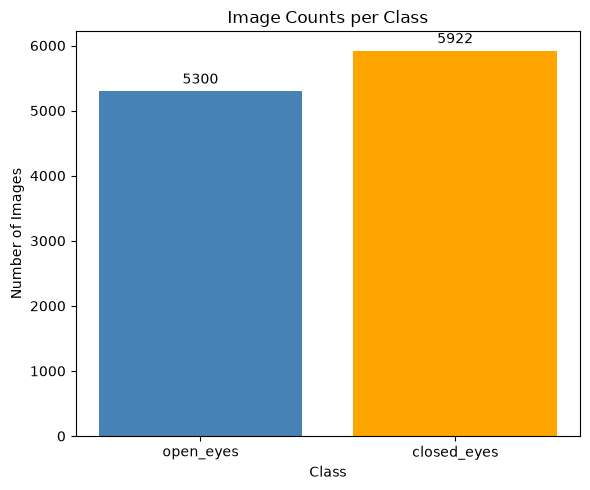

In [4]:
import matplotlib.pyplot as plt

classes = ['open_eyes', 'closed_eyes']
counts = [5300, 5922]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(classes, counts, color=['steelblue', 'orange'])
ax.set_title('Image Counts per Class')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

In [5]:
import os
from PIL import Image

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"

corrupt_files = []
sizes = set()
modes = set()

# Check every image for corruption, size and mode
for class_name in ['open_eyes', 'closed_eyes']:
    class_path = os.path.join(processed_path, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
            img = Image.open(img_path)
            sizes.add(img.size)
            modes.add(img.mode)
        except Exception as e:
            corrupt_files.append(img_path)

print(f"Total corrupt files: {len(corrupt_files)}")
print(f"Unique sizes found: {sizes}")
print(f"Unique modes found: {modes}")

Total corrupt files: 0
Unique sizes found: {(84, 84), (116, 116), (61, 61), (126, 126), (176, 176), (153, 153), (57, 57), (122, 122), (117, 117), (94, 94), (149, 149), (58, 58), (90, 90), (150, 150), (127, 127), (91, 91), (68, 68), (123, 123), (63, 63), (160, 160), (64, 64), (59, 59), (124, 124), (101, 101), (156, 156), (65, 65), (97, 97), (92, 92), (157, 157), (88, 88), (98, 98), (70, 70), (125, 125), (180, 180), (121, 121), (66, 66), (131, 131), (158, 158), (62, 62), (72, 72), (99, 99), (154, 154), (164, 164), (159, 159), (95, 95), (155, 155), (132, 132), (96, 96), (73, 73), (128, 128), (165, 165), (69, 69), (129, 129), (106, 106), (161, 161), (166, 166), (102, 102), (162, 162), (139, 139), (134, 134), (103, 103), (80, 80), (135, 135), (75, 75), (130, 130), (140, 140), (172, 172), (76, 76), (71, 71), (136, 136), (168, 168), (108, 108), (163, 163), (173, 173), (67, 67), (77, 77), (104, 104), (169, 169), (114, 114), (100, 100), (110, 110), (105, 105), (82, 82), (137, 137), (147, 147), 

In [6]:
import os
import hashlib
from PIL import Image

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"

seen_hashes = {}
duplicate_files = []

# Find and remove duplicate images
for class_name in ['open_eyes', 'closed_eyes']:
    class_path = os.path.join(processed_path, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        with open(img_path, 'rb') as f:
            img_hash = hashlib.md5(f.read()).hexdigest()
        if img_hash in seen_hashes:
            duplicate_files.append(img_path)
            os.remove(img_path)
        else:
            seen_hashes[img_hash] = img_path

print(f"Deleted {len(duplicate_files)} duplicate images")

Deleted 1 duplicate images


In [7]:
import os
import cv2

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"

BLUR_THRESHOLD = 10.0
blur_removed = 0

# Find and remove blurry images
for class_name in ['open_eyes', 'closed_eyes']:
    class_path = os.path.join(processed_path, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        blur_score = cv2.Laplacian(img, cv2.CV_64F).var()
        if blur_score < BLUR_THRESHOLD:
            os.remove(img_path)
            blur_removed += 1

print(f"Deleted {blur_removed} blurry images")
print("Cleaning complete!")

Deleted 1757 blurry images
Cleaning complete!


open_eyes: 4399 images
closed_eyes: 5065 images


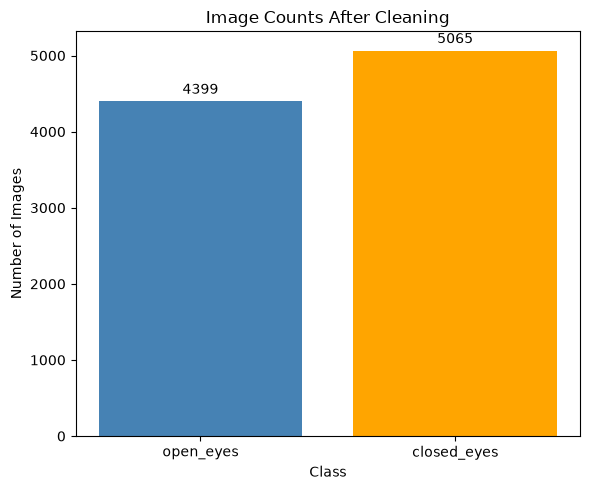

In [8]:
import os
import matplotlib.pyplot as plt

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"

classes = ['open_eyes', 'closed_eyes']
counts = []

# Count remaining images after cleaning
for class_name in classes:
    class_path = os.path.join(processed_path, class_name)
    count = len(os.listdir(class_path))
    counts.append(count)
    print(f"{class_name}: {count} images")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(classes, counts, color=['steelblue', 'orange'])
ax.set_title('Image Counts After Cleaning')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

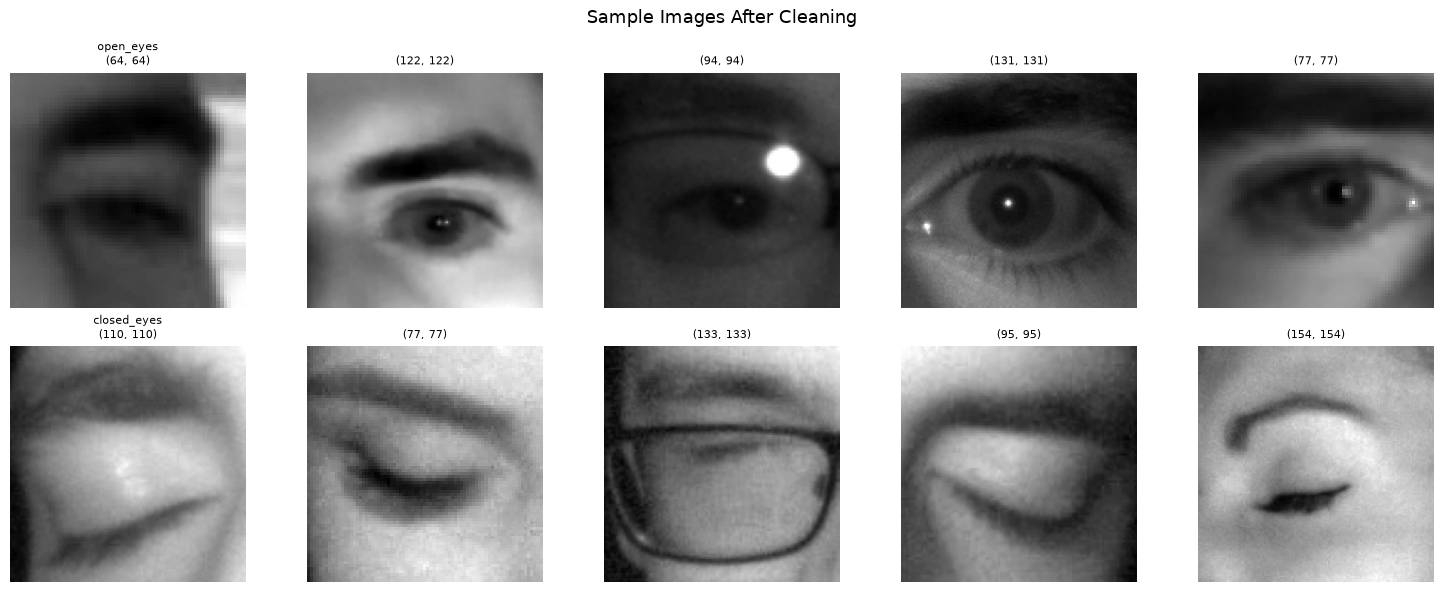

In [9]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"

classes = ['open_eyes', 'closed_eyes']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Show 5 random sample images from each class
for row, class_name in enumerate(classes):
    class_path = os.path.join(processed_path, class_name)
    images = random.sample(os.listdir(class_path), 5)
    for col, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        axes[row, col].set_title(f"{class_name if col == 0 else ''}\n{img.size}", fontsize=8)

plt.suptitle('Sample Images After Cleaning', fontsize=13)
plt.tight_layout()
plt.show()